In [139]:
import numpy as np
from matplotlib import pyplot as plt
import scipy
from functions.timestepping import *
from functions.rswes_functions import *

In [140]:
##################################################################
# Define the level of time-scale separation.
# Values of 0.5,0.1,0.05,0.01, 0.001 are used in the paper.
epsilon = 0.1

# Set a single large timestep size. 
# Values of 0.05, 0.1, ... 0.35 are used in the paper.
dt = 0.2

ic_type = 'Gaussian_mean_shift'

longer_time = False

TT = 10

# Pick averaging window sizes:
zeta = 1.25
eta_C = 2.8

t = np.arange(0,TT,dt) 

In [141]:


Nx = 32
Lx = 2*np.pi
dx = Lx/Nx
x = np.arange(0,Lx,dx)  

X,T = np.meshgrid(x,t)

k = np.fft.fftfreq(Nx,dx)*(2*np.pi)

# Create a de-aliasing array with top 2/3 of wavenumbers set to zero:
k_max = np.max(np.abs(k))

# Specify the strength of the 
# fourth-order hyperviscosity.
visc = 1e-4

# Nondimensional dispersion relation
psi = np.sqrt((1 + (k**2)))

# Time independent part of the matrix exponential
A = np.array([[psi/psi,(-1/psi),(1j*k/psi)],
             [(1/psi), (1/psi**2),(1j*k/(psi**2))],
             [(1j*k/psi),(1j*k/(psi**2)), (1/(psi**2))]])

###############################################################
# Initial condition
init = set_RSWE_initial_conditions(x, ic_type)

# Transform IC into spectral space
init_spec = np.fft.fft(init)

# Tolerance for the mean correction initial condition iteration
Ctol = 1e-10

In [142]:
# Base solution to compare errors relative to:

# Ref sol time step size
dt_b = 1e-2

if longer_time:
    U_analyt = np.load(f'reference_solutions/rswes/rswes_{ic_type}_eps{epsilon}_TT{TT}.npy')
else:
    U_analyt = np.load(f'reference_solutions/rswes/rswes_{ic_type}_eps{epsilon}.npy')

# Indices to compare with reference solution:
t_b = np.arange(0,TT+dt_b,dt_b)
inds = np.arange(0,len(t_b),int(np.rint(dt/dt_b)))
inds = np.asarray(inds)

if len(inds) != len(t):
    inds = inds[:-1]

# Parameters for the timestepping averaging kernel
K_min = 21 # Minimum number of sample points
KC_min = 21 # Minimum kernel points for the mean correction
ppp = 4 # averaging points per period
alpha = 4 # Kernel decay rate

U_analyt = U_analyt[:, inds, :]   

u_analyt = U_analyt[0,:]
v_analyt = U_analyt[1,:]
phi_analyt = U_analyt[2,:]

In [143]:
################################################################
# Standard phase averaging:
eta = zeta*dt
eta = np.round(eta,3)

#Set the required number of kernel points.
K_an = np.ceil(ppp*eta*np.max(psi)/(epsilon*2*np.pi))
K = int(max(K_an,K_min))

#If KC is odd, make it even
if (K%2):
    K = K + 1

print(f'zeta={zeta}, eta={eta}, K = {K} \n')

# Construct the kernel
s_vals, kernel = kernel_vals(K, eta, alpha)    

V_specs = np.asarray(RK4(etL_dot_N_aved, init_spec, t, dt, [kernel, s_vals, K, A, psi, k, visc, epsilon]))

# Components of the modulation variable solution
V_u = np.real(np.fft.ifft(V_specs[:,0,:]))
V_v = np.real(np.fft.ifft(V_specs[:,1,:]))
V_phi = np.real(np.fft.ifft(V_specs[:,2,:]))

# Convert back to the standard variable
#Now, get the proper solution variables.
U_specs = np.asarray(V_to_U(t, init_spec, V_specs, [A, psi, k, epsilon]))

C_U_u = np.real(np.fft.ifft(U_specs[:,0,:]))
C_U_v = np.real(np.fft.ifft(U_specs[:,1,:]))
C_U_phi = np.real(np.fft.ifft(U_specs[:,2,:]))

# Compute errors relative to the saved analytical solution:
C_u_err = np.sum(np.abs(C_U_u-u_analyt),axis=1)
C_v_err = np.sum(np.abs(C_U_v-v_analyt),axis=1)
C_phi_err = np.sum(np.abs(C_U_phi-phi_analyt),axis=1)

# Sum the component errors:
C_err = np.sqrt(C_u_err**2 + C_v_err**2 + C_phi_err**2)
C_err_sum = np.sum(C_err)/len(t)

##################################################
# Mean correction:
eta_C = np.round(eta_C,3)

#Set the required number of kernel points.
KC_an = np.ceil(ppp*eta_C*np.max(psi)/(epsilon*2*np.pi))
KC = int(max(KC_an,KC_min))

#If KC is odd, make it even
if (KC%2):
    KC = KC + 1

print(f'eta_C={eta_C}, KC={KC} \n')

#Construct the kernel
global kernel_C, s_vals_C
s_vals_C, kernel_C = kernel_vals(KC, eta_C, alpha)    

#################################################
# Hmm, double check this .... ... .. .
e_sL_ave = np.zeros((3,3,Nx),dtype='complex128')
eC_sL_ave = np.zeros((3,3,Nx),dtype='complex128')

for q in np.arange(K):
    s = s_vals[q]
    B = B_mat(s, [psi, k, epsilon])
    e_sL_ave += kernel[q]*np.multiply(A,B)
    
for q in np.arange(KC):
    s = s_vals_C[q]
    B = B_mat(s, [psi, k, epsilon])
    eC_sL_ave += kernel_C[q]*np.multiply(A,B)

#############################################

meancor_args = [kernel, s_vals, K, kernel_C, s_vals_C, KC, A, psi, k, visc, epsilon, e_sL_ave]
C_vals, U_specs, W_specs = mean_cor_phase_aved_RK4(init_spec,t,dt, meancor_args)

U_specs = np.asarray(U_specs)

D_U_u = np.real(np.fft.ifft(U_specs[:,0,:]))
D_U_v = np.real(np.fft.ifft(U_specs[:,1,:]))
D_U_phi = np.real(np.fft.ifft(U_specs[:,2,:]))

D_U_u = np.real(np.fft.ifft(U_specs[:,0,:]))
D_U_v = np.real(np.fft.ifft(U_specs[:,1,:]))
D_U_phi = np.real(np.fft.ifft(U_specs[:,2,:]))

# Compute errors relative to the saved analytical solution:
D_u_err = np.sum(np.abs(D_U_u-u_analyt),axis=1)
D_v_err = np.sum(np.abs(D_U_v-v_analyt),axis=1)
D_phi_err = np.sum(np.abs(D_U_phi-phi_analyt),axis=1)

# Sum the component errors:
D_err = np.sqrt(D_u_err**2 + D_v_err**2 + D_phi_err**2)
D_err_sum = np.sum(D_err)/len(t)

print('Standard error is ', C_err_sum)
print('Mean corrected error is', D_err_sum)


zeta=1.25, eta=0.25, K = 26 

eta_C=2.8, KC=286 

Standard error is  0.05382732269722018
Mean corrected error is 0.047455334943774685


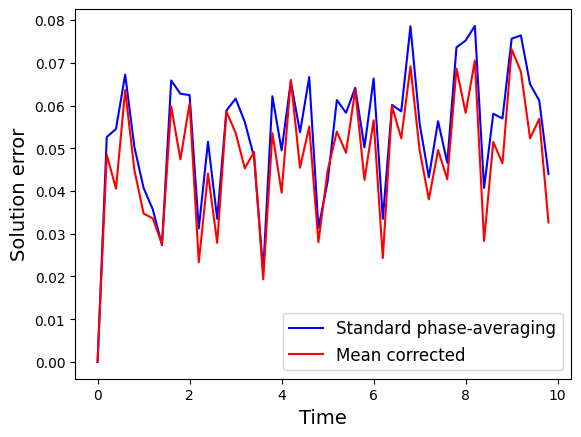

In [144]:
plt.figure()
plt.plot(t, C_err, label='Standard phase-averaging', c='b')
plt.plot(t, D_err, label='Mean corrected', c='r')
plt.xlabel('Time', size=14)
plt.ylabel('Solution error', size=14)
plt.legend(fontsize=12)

(50, 3, 32)


Text(0.5, 0.98, 'Comparing geopotential Solutions')

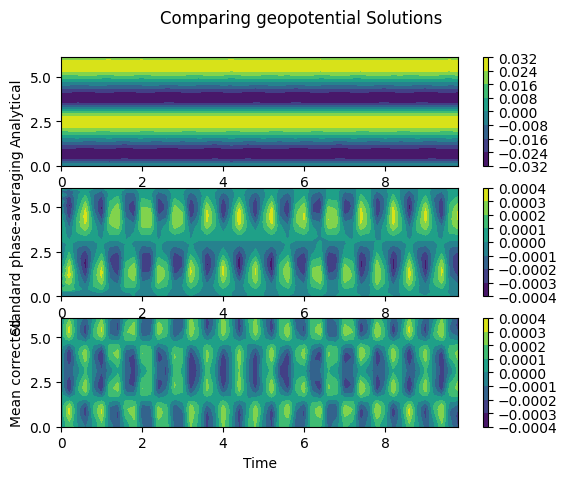

In [145]:
# Plot the mean correction!
print(np.shape(C_vals))
C_vals = np.asarray(C_vals)

C_phys_u = np.fft.ifft(C_vals[:,0,:])
C_phys_v = np.fft.ifft(C_vals[:,1,:])
C_phys_phi = np.fft.ifft(C_vals[:,2,:])

fig, (ax1,ax2,ax3) = plt.subplots(3,1)
fig1 = ax1.contourf(T,X,C_phys_u)
ax1.set_ylabel('Analytical')
plt.colorbar(fig1,ax=ax1)
fig2 = ax2.contourf(T,X,C_phys_v)
ax2.set_ylabel('Standard phase-averaging')
plt.colorbar(fig2,ax=ax2)
fig3 = ax3.contourf(T,X,C_phys_phi)
ax3.set_ylabel('Mean corrected')
ax3.set_xlabel('Time')
plt.colorbar(fig3,ax=ax3)
plt.suptitle('Comparing geopotential Solutions')
